In [1]:
import random
import numpy as np
import tqdm.notebook as tqdm
import matplotlib.pyplot as plt
from tqdm import tqdm

# 1: Complete the Implementation of the Four Rooms environment

- The FourRooms is implemented as a python class. We explain the attributes and methods as follows
    - **init** function: Define all the attributes of the Four Rooms environment. For example, the state space, the action space, the start state, the goal state and so on.
    - **reset** function: Resets the agent to the start state (0, 0)
    - **step** function: Takes the current state and one action, returns the next state and a reward
   
- Please complete the implementation in the step function.

In [2]:
# FOUR ROOM ENVIRONMENT
class FourRooms(object):
    def __init__(self):
        """
        Four-room stochastic environment as a 2D array.
        Stochastic: with 80% probability, the agent performs the chosen action, and goes in a perpendicular direction with 10% chance.
        0 represents an empty cell; 1 represents a wall cell.
        The origin of the environment is at the bottom-left.
        """
        self.four_room_space = np.array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])

        
        # The origin for a 2-D numpy array is located at top-left, while the origin for the FourRooms is at the bottom-left.
        # The following code performs the re-projection.
        empty_cells = np.where(self.four_room_space == 0.0)
        walls = np.where(self.four_room_space == 1.0)
        self.state_space = [[col, 10 - row] for row, col in zip(empty_cells[0], empty_cells[1])] # Possible states where agent can be in
        self.walls_space = [[col, 10 - row] for row, col in zip(walls[0], walls[1])]  # might not be needed ahead

        self.action_space = {'LEFT': np.array([-1, 0]),
                             'RIGHT': np.array([1, 0]),
                             'DOWN': np.array([0, -1]),
                             'UP': np.array([0, 1])}
        self.start_state = [0, 0]
        self.goal_state = [10, 10]


    def reset(self):
        """
        Reset the agent's state to the start state [0, 0]
        Return both the start state and reward
        """
        state = self.start_state  # reset the agent to [0, 0]
        reward = 0  # no reward at start state
        return state, reward


    def step(self, state, act):
        """
        Args:
            state: a list variable containing x, y integer coordinates. (i.e., [1, 1]).
            act: a string variable (i.e., "UP"). All feasible values are ["UP", "DOWN", "LEFT", "RIGHT"].
        Output args:
            next_state: a list variable containing x, y integer coordinates (i.e., [1, 1])
            reward: an integer, either 0 or 1.
        """
        next_state = None
        if(act == "LEFT" or act == "RIGHT"):
            curr_action = np.random.choice([act, "UP", "DOWN"], 1, p=[0.8, 0.1, 0.1]).tolist()[0]
        if(act == "UP" or act == "DOWN"):
            curr_action = np.random.choice([act, "LEFT", "RIGHT"], 1, p=[0.8, 0.1, 0.1]).tolist()[0]

        # Perform this action 
        next_state = self.take_action(state, curr_action)
        # Checking Out of bounds:
        if(next_state[0] == 11 or next_state[0] == -1 or next_state[1] == 11 or next_state[1] == -1):
            next_state = state
        # Checking if we hit a wall
        if(next_state in self.walls_space):
            next_state = state

        # compute the reward based on the resulting state
        reward = 0
        if(next_state == self.goal_state):
            reward = 1
            self.reset()
        # return the current state, reward
        return next_state, reward

    def take_action(self, state, act):
        """
        Input args:
            state (list): a list variable containing x, y integer coordinates. (i.e., [1, 1]).
            act (string): a string variable (i.e., "UP"). All feasible values are ["UP", "DOWN", "LEFT", "RIGHT"].
        Output args:
            next_state (list): a list variable containing x, y integer coordinates (i.e., [1, 1])
        """
        state = np.array(state)
        next_state = state + self.action_space[act]
        return next_state.tolist() if next_state.tolist() in self.state_space else state.tolist()

In [3]:
def plot_func(res_list):
    plt.figure(figsize=(8, 6))
    
    # plot each trial
    for re in res_list:
        plt.plot(list(range(len(res_list[0]))), re, linestyle="--", linewidth=1, alpha=0.7)

    # plot mean reward
    mean_reward = np.array(res_list).mean(axis=0).tolist()
    plt.plot(list(range(len(res_list[0]))), mean_reward, linestyle="-", linewidth=2, color="k")

    # plot the figure
    plt.ylabel("Cumulative reward")
    plt.xlabel("Time step")
    plt.show()

# 2 Implement the manual policy

In [4]:
def manual_policy(state):
    """
    A manual policy that takes action as an input from the user.

    Input args:
        state (list): a list variable containing x, y integer coordinates. (i.e., [1, 1]).
    Output args:
        action (string): a string variable (i.e., "UP").
    """
    a = input("Enter an action (UP, DOWN, LEFT, RIGHT): ")
    while(True):
        if a in ["UP", "DOWN", "LEFT", "RIGHT"]:
            break
        else:
            a = input("Enter an action (UP, DOWN, LEFT, RIGHT): ")
    return a

In [5]:
if __name__ == "__main__":
    # fix the randomness for reproduction
    random.seed(1234)
    np.random.seed(1234)

    # create the environment
    env = FourRooms()
    state, reward = env.reset()  

    time_step = 3

    # create a loop
    for t in range(time_step):
        action = manual_policy(state)
        next_state, reward = env.step(state, action)
        # print interaction
        print(f"Step = {t}, state = {state}, action = {action}, next state = {next_state}, reward = {reward}")

        # reset if the agent reaches the goal
        if reward == 1:
            print("Reset the agent to the start state!")
            state, reward = env.reset()
        else:
            state = next_state

Enter an action (UP, DOWN, LEFT, RIGHT):  UP


Step = 0, state = [0, 0], action = UP, next state = [0, 1], reward = 0


Enter an action (UP, DOWN, LEFT, RIGHT):  UP


Step = 1, state = [0, 1], action = UP, next state = [0, 2], reward = 0


Enter an action (UP, DOWN, LEFT, RIGHT):  RIGHT


Step = 2, state = [0, 2], action = RIGHT, next state = [1, 2], reward = 0


# 3. Implement a random policy

Run trial: 100%|████████████████████████████████| 10/10 [00:03<00:00,  2.58it/s]


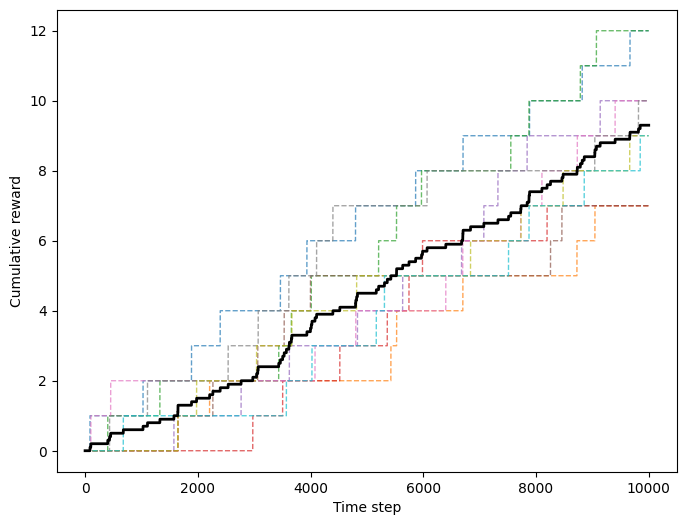

In [6]:
if __name__ == "__main__":
    # fix the randomness for reproduction
    random.seed(1234)
    np.random.seed(1234)

    # create the environment
    env = FourRooms()
    # number of the trails
    trial_num = 10
    # length of each trail
    trial_length = int(1e4)

    # save the rewards for plot
    rewards_list = []

    # run experiment
    for e in tqdm(range(trial_num), desc="Run trial",position=0):
        # reset for every trail
        reward_per_trial = []
        reward_counter = 0

        # reset the environment
        state, reward = env.reset()

        # run each trial
        for t in tqdm(range(trial_length), desc="Episode", position=1, leave=True):
            possible_actions = ["UP", "DOWN", "LEFT", "RIGHT"]
            ind = random.randint(0,3)
            action = possible_actions[ind]
            next_state, reward = env.step(state, action)
            
            reward_counter += reward
            reward_per_trial.append(reward_counter)

            # reset
            if reward == 1:
                state, reward = env.reset()
            else:
                state = next_state

        # save the rewards
        rewards_list.append(reward_per_trial)

# PLOT THE RESULTS
plot_func(rewards_list)

# 4. Implement better & worse policies against the Random Policy

For a worse policy, we can have an agent that just keeps going, say RIGHT trying to reach the goal. We know from the environment dynamics that such a policy would never reach the goal state.

Run trial: 100%|████████████████████████████████| 10/10 [00:03<00:00,  2.57it/s]


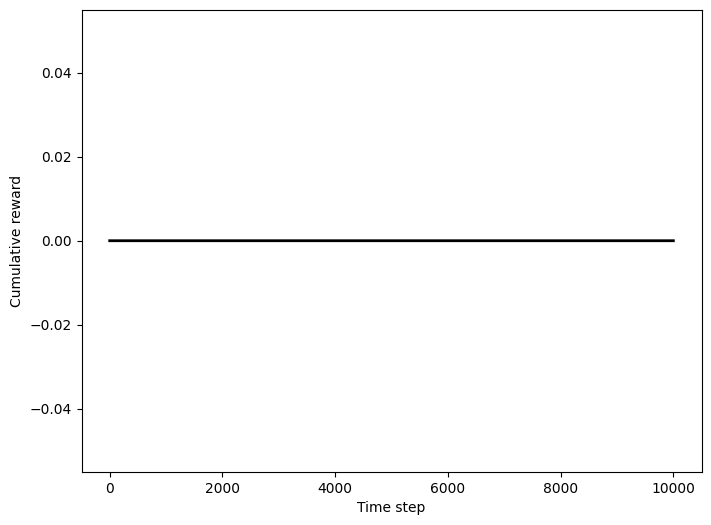

In [7]:
if __name__ == "__main__":
    # fix the randomness for reproduction
    random.seed(1234)
    np.random.seed(1234)
    env = FourRooms()
    trial_num = 10
    trial_length = int(1e4)

    # save the rewards for plot
    rewards_list = []

    # run experiment
    for e in tqdm(range(trial_num), desc="Run trial",position=0):
        reward_per_trial = []
        reward_counter = 0
        state, reward = env.reset()
        for t in tqdm(range(trial_length), desc="Episode", position=1, leave=False):
            # Policy that is worse than the random policy.
            action = "RIGHT"
            next_state, reward = env.step(state, action)
            reward_counter += reward
            reward_per_trial.append(reward_counter)

            # reset
            if reward == 1:
                state, reward = env.reset()
            else:
                state = next_state

        # save the rewards
        rewards_list.append(reward_per_trial)

# PLOT THE RESULTS
plot_func(rewards_list)

Since the environment is known to the agent, a better policy will make use of this information given by the environment. Hence, a better policy can explicitly be instructed to follow a possible path from the start.

Run trial: 100%|████████████████████████████████| 10/10 [00:03<00:00,  2.59it/s]


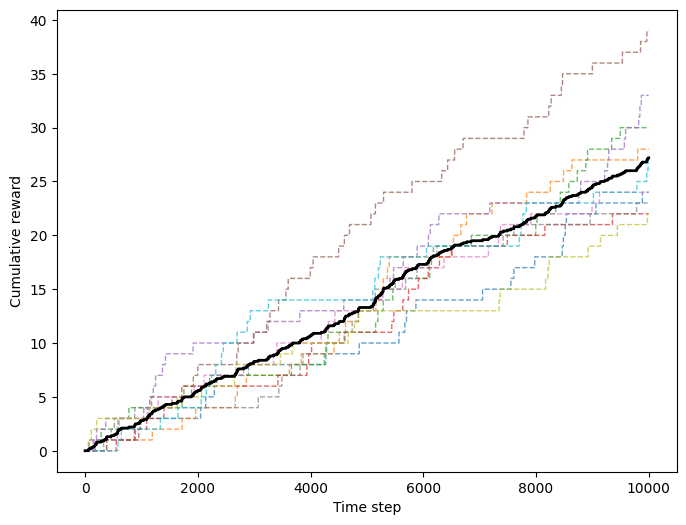

In [8]:
if __name__ == "__main__":
    # fix the randomness for reproduction
    random.seed(1234)
    np.random.seed(1234)
    env = FourRooms()
    trial_num = 10
    trial_length = int(1e4)
    rewards_list = []

    # run experiment
    for e in tqdm(range(trial_num), desc="Run trial",position=0):
        reward_per_trial = []
        reward_counter = 0
        state, reward = env.reset()
        counter = 0
        # run each trial
        for t in tqdm(range(trial_length), desc="Episode", position=1, leave=False):
            # A better policy than random (encoded path)
            action_list = ["RIGHT", "UP", "UP", "UP", "UP", "UP", "UP", "UP", "UP", "RIGHT", "RIGHT", "RIGHT", "RIGHT", "RIGHT", "RIGHT", "RIGHT", "RIGHT", "RIGHT", "UP", "UP"]
            counter = counter % 20
            action = action_list[counter]
            next_state, reward = env.step(state, action)
            reward_counter += reward
            reward_per_trial.append(reward_counter)

            # reset
            if reward == 1:
                state, reward = env.reset()
                counter = 0
            else:
                state = next_state
                counter += 1

        # save the rewards
        rewards_list.append(reward_per_trial)

# PLOT THE RESULTS
plot_func(rewards_list)

Since this has more cumulative reward compared to the random policy for same number of timesteps, it is clearly a better policy.